# Regressão 01 - tarefa 01

### 1. Explorando a base de gorjetas

a. Na aula fizemos uma regressão de ```tip``` explicada por ```net_bill```. Carregue os pacotes e a base, crie as variáveis necessárias como na aula, e reproduza esta regressão.

b. Reproduza também o gráfico de dispersão dessas duas variáveis.

In [ ]:
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

#carregar base
tips = sns.load_dataset('tips')

#Criar variavel net_bill (conta sem gorjeta)
tips['net_bill'] = tips['total_bill'] - tips['tip']

#Regressão
reg1 = smf.ols('tips ~ net_bill', data=tips).fit()

print(reg.summary())

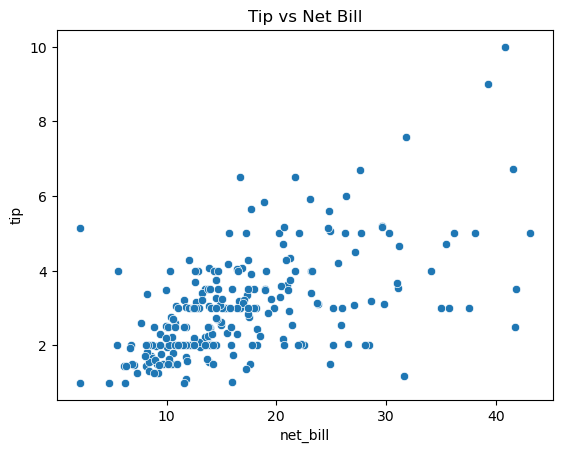

In [8]:
#Grafico de dispersão
sns.scatterplot(x='net_bill', y='tip', data=tips)
plt.title('Tip vs Net Bill')
plt.show()

### 2. Mudança de perspectiva

Agora ajuste um modelo de regressão de ```tip_pct``` por ```net_bill```. Construa o gráfico de dispersão correspondente.

In [14]:
# Percentual de gorjeta
tips['tip_pct'] = tips['tip'] / tips['net_bill']

# Regressão
reg2 = smf.ols('tip_pct ~ net_bill', data=tips).fit()

print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     24.31
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.52e-06
Time:                        20:49:21   Log-Likelihood:                 108.00
No. Observations:                 244   AIC:                            -212.0
Df Residuals:                     242   BIC:                            -205.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3053      0.023     13.166      0.0

### 3. Comente

Compare os dois gráficos e comente (de forma objetiva e suscinta) a relação entre eles e a diferença do ajuste. Podemos comparar diretamente os $R^2$s?

O primeiro gráfico (tip vs net_bill) apresenta uma relação linear positiva clara, indicando que quanto maior a conta, maior o valor da gorjeta. Já o segundo gráfico (tip_pct vs net_bill) mostra maior dispersão e uma relação mais fraca, sugerindo que o percentual da gorjeta não cresce proporcionalmente ao valor da conta.

Não podemos comparar diretamente os 
𝑅
2
R
2
 dos modelos, pois as variáveis dependentes são diferentes (tip vs tip_pct), o que altera a escala e a variabilidade dos dados.

### 4. Ajuste do modelo em outra escala

Com o modelo no item 3, obtenha a preditiva do valor da gorjeta:
  1. obtenha o valor predito ```pred``` para ```tip_pct``` (dica, veja o atributo ```reg.fittedvalues```)
  2. obtenha o valor predito para ```tip``` como ```tip_pct * net_bill```
  3. calcule o $R^2$ do modelo para ```tip```
  4. compare esse $R^2$ com o do item 1

In [17]:
# Predição do tip_pct
tips['pred_tip_pct'] = reg2.fittedvalues

# Converter para valor de gorjeta
tips['pred_tip'] = tips['pred_tip_pct'] * tips['net_bill']

In [ ]:
#Calcular R² manual para tip
# Soma dos quadrados dos resíduos
resid = tips['tip'] - tips['pred_tip']
ss_res = (resid**2).sum()

# Soma total
ss_tot = ((tips['tip'] - tips['tip'].mean())**2).sum()

# R²
r2_tip = 1 - (ss_res / ss_tot)

print('R² modelo ajustado:', r2_tip)

O R^2 do modelo ajustado via tip_pct tende a ser menor do que o modelo direto de tip ~ net_bill, pois ao transformar a variável dependente em percentual, aumentamos a variabilidade e reduzimos a capacidade explicativa do modelo.